In [1]:
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우는 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==============================================================================
# [함수 1] RFM 및 주기성 파생변수 생성
# ==============================================================================
def create_rfm_features(trans_df, base_date_str='2023-12-31'):
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    base_date = pd.to_datetime(base_date_str)
    
    def get_rfm_by_days(days, prefix):
        cutoff = base_date - pd.Timedelta(days=days)
        temp = trans_df[trans_df['trans_date'] >= cutoff]
        return temp.groupby('customer_id').agg(
            freq=(f'trans_id', 'count'),
            money=(f'trans_amount', 'sum')
        ).rename(columns={'freq': f'freq_{prefix}', 'money': f'money_{prefix}'})

    periods = {7: '7d', 15: '15d', 30: '30d', 60: '60d', 90: '90d', 180: '180d'}
    rfm_frames = [get_rfm_by_days(days, prefix) for days, prefix in periods.items()]
        
    rfm_base = trans_df.groupby('customer_id').agg(
        recency=('trans_date', lambda x: (base_date - x.max()).days),
        total_freq=('trans_id', 'count'),
        total_money=('trans_amount', 'sum')
    ).reset_index()
    
    for frame in rfm_frames:
        rfm_base = rfm_base.merge(frame, on='customer_id', how='left')
    rfm_base.fillna(0, inplace=True)

    trans_df = trans_df.sort_values(['customer_id', 'trans_date'])
    trans_df['days_diff'] = trans_df.groupby('customer_id')['trans_date'].diff().dt.days
    interval_stats = trans_df.groupby('customer_id')['days_diff'].agg(['mean', 'std']).reset_index()
    interval_stats.columns = ['customer_id', 'avg_interval', 'interval_std']
    interval_stats.fillna(0, inplace=True)
    
    rfm_df = rfm_base.merge(interval_stats, on='customer_id', how='left')
    
    # 킬러 파생변수 세트
    rfm_df['relative_recency'] = rfm_df['recency'] / (rfm_df['avg_interval'] + 1e-6)
    rfm_df['consistency_risk'] = rfm_df['relative_recency'] * (1 / (rfm_df['interval_std'] + 1))
    rfm_df['short_term_drop_7d'] = (rfm_df['money_30d'] / 4) - rfm_df['money_7d']
    rfm_df['short_term_drop_15d'] = (rfm_df['money_30d'] / 2) - rfm_df['money_15d']
    rfm_df['avg_ticket_size'] = np.log1p(rfm_df['total_money'] / (rfm_df['total_freq'] + 1e-6))
    
    return rfm_df

In [3]:
# ==============================================================================
# [함수 2] 재무/부채 파생변수 생성
# ==============================================================================
def create_finance_features(finance_df):
    fin_df = finance_df.copy()
    fin_df['total_debt'] = fin_df['card_cash_service_amt'] + fin_df['card_loan_amt'] + fin_df['total_loan_balance']
    fin_df['debt_to_asset_ratio'] = np.log1p(fin_df['total_debt'] / (fin_df['total_deposit_balance'] + 1))
    fin_df['has_card_loan'] = (fin_df['card_loan_amt'] > 0).astype(int)
    fin_df['has_overdue'] = (fin_df['fin_overdue_days'] > 0).astype(int)
    return fin_df

In [4]:
# ==============================================================================
# [함수 3] 취향 일치도 파생변수 생성
# ==============================================================================
def create_preference_features(info_df, trans_df, actual_cat_col='item_category'):
    temp_trans = trans_df.merge(info_df[['customer_id', 'prefer_category']], on='customer_id', how='left')
    temp_trans['is_pref_spend'] = (temp_trans[actual_cat_col] == temp_trans['prefer_category']).astype(int)
    temp_trans['pref_category_amount'] = temp_trans['trans_amount'] * temp_trans['is_pref_spend']

    pref_match_df = temp_trans.groupby('customer_id').agg(
        pref_spend_sum=('pref_category_amount', 'sum'),
        total_spend=('trans_amount', 'sum')
    ).reset_index()

    pref_match_df['pref_spend_ratio'] = pref_match_df['pref_spend_sum'] / (pref_match_df['total_spend'] + 1e-6)
    return pref_match_df[['customer_id', 'pref_spend_ratio']]

In [21]:
# ==============================================================================
# [함수 4] 전처리 파이프라인
# ==============================================================================
def preprocess_pipeline(info_df, finance_df, trans_df, targets_df):
    print("▶️ 데이터를 병합하고 파생변수를 생성합니다...")
    rfm_df = create_rfm_features(trans_df)
    fin_df = create_finance_features(finance_df)
    pref_df = create_preference_features(info_df, trans_df, actual_cat_col='item_category')
    
    df = info_df.merge(rfm_df, on='customer_id', how='left')
    df = df.merge(fin_df, on='customer_id', how='left')
    df = df.merge(pref_df, on='customer_id', how='left')
    df = df.merge(targets_df, on='customer_id', how='inner')
    df.fillna(0, inplace=True)
    
    # [함수 4] 전처리 파이프라인 데이터 병합 직후에 추가
    # 🔥 1. 총자산 대비 누적 소비액 (자산이 적은데 소비가 많으면 위험)
    df['spend_to_asset_ratio'] = df['total_money'] / (df['total_deposit_balance'] + 1)

    # 🔥 2. 총부채 대비 누적 소비액 (빚이 많은데 소비가 줄어들면 한계 상황)
    df['debt_to_spend_ratio'] = df['total_debt'] / (df['total_money'] + 1)

    # 🔥 3. 신용점수 구간화 (수치형인 신용점수를 범주형으로 묶어 트리 모델이 인식하기 쉽게 함)
    df['credit_tier'] = pd.qcut(df['credit_score'], q=5, labels=False)
    
    # ==============================================================================
    # 🔥 [FP 감소용] 재무 + 행동(RFM) 융합 크로스 변수
    # ==============================================================================

    # 1. 생계형 활성 고객 (대출은 있지만 최근 15일 이내에 결제한 사람 -> 이탈 안 함!)
    df['active_borrower'] = ((df['has_card_loan'] == 1) & (df['recency'] <= 15)).astype(int)

    # 2. 진짜 위험군 (대출도 있는데, 평소 주기보다 2배 이상 안 들어오는 사람 -> 찐 이탈!)
    df['loan_and_silent'] = ((df['has_card_loan'] == 1) & (df['relative_recency'] >= 2.0)).astype(int)

    # 3. 빈도 대비 대출금액 (결제는 안 하는데 빚만 많은 상태를 수치화)
    df['loan_to_freq_ratio'] = df['card_loan_amt'] / (df['total_freq'] + 1)
        
    cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')
            
    drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date', 'trans_date']
    features = [c for c in df.columns if c not in drop_cols]
    
    X = df[features]
    y = df['target_churn']
    useless_features = [
        'num_active_cards', 'avg_ticket_size', 'fin_overdue_days', 
        'freq_30d', 'freq_15d', 'freq_60d', 'has_overdue', 'gender'
    ]
    df.drop(columns=[col for col in useless_features if col in df.columns], inplace=True)
    print(f"🗑️ 노이즈 피처 {len(useless_features)}개 제거 완료")
    
    return X, y, features

In [20]:
# ==============================================================================
# [함수 5] Optuna를 활용한 XGBoost 튜닝 (과적합 방지 강력 규제 적용)
# ==============================================================================
def optimize_xgboost(X, y):
    print("\n🚀 K-Fold 및 과적합 방지(Regularization) 정밀 튜닝을 시작합니다...")
    
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            # 과적합 방지 핵심 파라미터들 (깊이 제한, 가지치기, 가중치 규제)
            'max_depth': trial.suggest_int('max_depth', 3, 6),           # 깊이 제한 (기존 8 -> 6)
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 20), # 노드 분할 최소 조건 강화
            'gamma': trial.suggest_float('gamma', 1.0, 10.0),             # 가지치기 엄격도
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True), # L1 규제 (불필요 변수 차단)
            'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),# L2 규제 (극단적 예측 방지)
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
            'max_delta_step': trial.suggest_int('max_delta_step', 1, 5),
            'tree_method': 'hist',          
            'enable_categorical': True,     
            'early_stopping_rounds': 50, 
            'random_state': 42,
            'n_jobs': -1
        }
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc_scores = []
        
        for train_idx, val_idx in cv.split(X, y):
            X_f_train, y_f_train = X.iloc[train_idx], y.iloc[train_idx]
            X_f_val, y_f_val = X.iloc[val_idx], y.iloc[val_idx]
            
            model = xgb.XGBClassifier(**param)
            model.fit(
                X_f_train, y_f_train, 
                eval_set=[(X_f_val, y_f_val)], 
                verbose=False
            )
            
            preds = model.predict_proba(X_f_val)[:, 1]
            auc_scores.append(roc_auc_score(y_f_val, preds))
            
        return np.mean(auc_scores)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=20) 
    
    print(f"✅ 최적의 K-Fold ROC-AUC 점수: {study.best_value:.4f}")
    return study.best_params

In [7]:
# ==============================================================================
# 🎯 메인 실행 블록 (여기부터 주석을 풀고 실행하세요)
# ==============================================================================
# 1. 데이터 로드 (경로를 실제 환경에 맞게 수정하세요)
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv')

In [22]:
# 2. 전처리 실행
X, y, feature_names = preprocess_pipeline(info_df, finance_df, trans_df, targets_df)

# 3. Train / Valid 단일 분할 (K-Fold 대신)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

▶️ 데이터를 병합하고 파생변수를 생성합니다...
🗑️ 노이즈 피처 8개 제거 완료


In [23]:
# 4. 하이퍼파라미터 최적화 (XGBoost)
best_params = optimize_xgboost(X_train, y_train)

[I 2026-04-13 14:56:33,622] A new study created in memory with name: no-name-a5f86fc6-fc78-410b-9651-d42da4998a8a



🚀 K-Fold 및 과적합 방지(Regularization) 정밀 튜닝을 시작합니다...


[I 2026-04-13 14:56:34,956] Trial 0 finished with value: 0.7986971589982486 and parameters: {'n_estimators': 425, 'learning_rate': 0.08927180304353628, 'max_depth': 5, 'min_child_weight': 14, 'gamma': 2.4041677639819286, 'reg_alpha': 0.029375384576328302, 'reg_lambda': 0.014936568554617643, 'subsample': 0.8598528437324806, 'colsample_bytree': 0.7803345035229626, 'max_delta_step': 4}. Best is trial 0 with value: 0.7986971589982486.
[I 2026-04-13 14:56:36,405] Trial 1 finished with value: 0.7973607489054537 and parameters: {'n_estimators': 212, 'learning_rate': 0.09330606024425668, 'max_depth': 6, 'min_child_weight': 8, 'gamma': 2.636424704863906, 'reg_alpha': 0.03549878832196503, 'reg_lambda': 0.08179499475211674, 'subsample': 0.7574269294896714, 'colsample_bytree': 0.7295835055926347, 'max_delta_step': 2}. Best is trial 0 with value: 0.7986971589982486.
[I 2026-04-13 14:56:41,196] Trial 2 finished with value: 0.7984260873335989 and parameters: {'n_estimators': 567, 'learning_rate': 0.0

✅ 최적의 K-Fold ROC-AUC 점수: 0.7991


In [24]:
# 5. 최종 모델 학습
best_params['tree_method'] = 'hist'
best_params['enable_categorical'] = True
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# 예측 수행
valid_preds = final_model.predict_proba(X_valid)[:, 1]
print(f"\n🔥 최종 Validation ROC-AUC Score: {roc_auc_score(y_valid, valid_preds):.4f}")


🔥 최종 Validation ROC-AUC Score: 0.7867


In [25]:
# ==============================================================================
# 🔍 [기능 개선] 최적의 임계값(Threshold) 찾기 로직
# ==============================================================================
# 확률이 너무 낮게 나오므로, 0.5가 아닌 가장 1을 잘 찾아내는 최적의 기준선을 찾습니다.
best_threshold = 0.5
best_f1 = 0

for thresh in np.arange(0.05, 0.55, 0.05):
    preds_binary = (valid_preds >= thresh).astype(int)
    current_f1 = f1_score(y_valid, preds_binary)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"💡 [Threshold 최적화] 기존 0.5 대신 {best_threshold:.2f}을(를) 기준으로 이탈을 판별합니다.")
print(f"   (이 기준을 사용할 때 이탈자를 가장 밸런스 있게 잘 찾아냅니다.)\n")

# 최적 임계값 적용한 최종 예측 클래스
final_preds_binary = (valid_preds >= best_threshold).astype(int)

💡 [Threshold 최적화] 기존 0.5 대신 0.20을(를) 기준으로 이탈을 판별합니다.
   (이 기준을 사용할 때 이탈자를 가장 밸런스 있게 잘 찾아냅니다.)



In [26]:
# ==============================================================================
# 📊 [텍스트 출력] 피처 중요도 상위/하위 10개
# ==============================================================================
feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("="*60)
print("🏆 [모델 하드캐리] 피처 중요도 Top 10:")
for idx, row in feature_imp.head(10).iterrows():
    print(f"  {idx+1:2d}위: {row['Feature']:<25} ({row['Importance']:.4f})")

print("\n🗑️ [삭제 권장] 피처 중요도 Bottom 10 (모델이 무시함):")
for idx, row in feature_imp.tail(10).iterrows():
    print(f"  - {row['Feature']:<25} ({row['Importance']:.4f})")
print("="*60)

🏆 [모델 하드캐리] 피처 중요도 Top 10:
   1위: has_card_loan             (0.1859)
   2위: fin_asset_trend_score     (0.1813)
   3위: loan_to_freq_ratio        (0.0701)
   4위: total_deposit_balance     (0.0659)
   5위: card_loan_amt             (0.0550)
   6위: spend_to_asset_ratio      (0.0428)
   7위: active_borrower           (0.0260)
   8위: card_cash_service_amt     (0.0211)
   9위: debt_to_asset_ratio       (0.0171)
  10위: total_debt                (0.0171)

🗑️ [삭제 권장] 피처 중요도 Bottom 10 (모델이 무시함):
  - short_term_drop_7d        (0.0077)
  - freq_180d                 (0.0077)
  - recency                   (0.0075)
  - freq_7d                   (0.0075)
  - num_active_cards          (0.0074)
  - is_married                (0.0074)
  - income_group              (0.0073)
  - freq_60d                  (0.0069)
  - has_overdue               (0.0064)
  - loan_and_silent           (0.0000)


In [27]:
# ==============================================================================
# 📊 [텍스트 출력] 혼동 행렬 및 분류 리포트
# ==============================================================================
cm = confusion_matrix(y_valid, final_preds_binary)
print("[최종 혼동 행렬 (Confusion Matrix)]")
print(f"  - 실제 유지(0) 맞춤 (TN): {cm[0,0]}")
print(f"  - 실제 이탈(1) 맞춤 (TP): {cm[1,1]}  👈 우리가 찾아낸 이탈자 수!")
print(f"  - 이탈이라 우겼지만 유지 (FP): {cm[0,1]} (오탐지)")
print(f"  - 유지라 우겼지만 이탈 (FN): {cm[1,0]} (놓친 고객)\n")

print("[상세 분류 리포트]")
print(classification_report(y_valid, final_preds_binary))

[최종 혼동 행렬 (Confusion Matrix)]
  - 실제 유지(0) 맞춤 (TN): 9474
  - 실제 이탈(1) 맞춤 (TP): 644  👈 우리가 찾아낸 이탈자 수!
  - 이탈이라 우겼지만 유지 (FP): 1340 (오탐지)
  - 유지라 우겼지만 이탈 (FN): 542 (놓친 고객)

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     10814
           1       0.32      0.54      0.41      1186

    accuracy                           0.84     12000
   macro avg       0.64      0.71      0.66     12000
weighted avg       0.88      0.84      0.86     12000



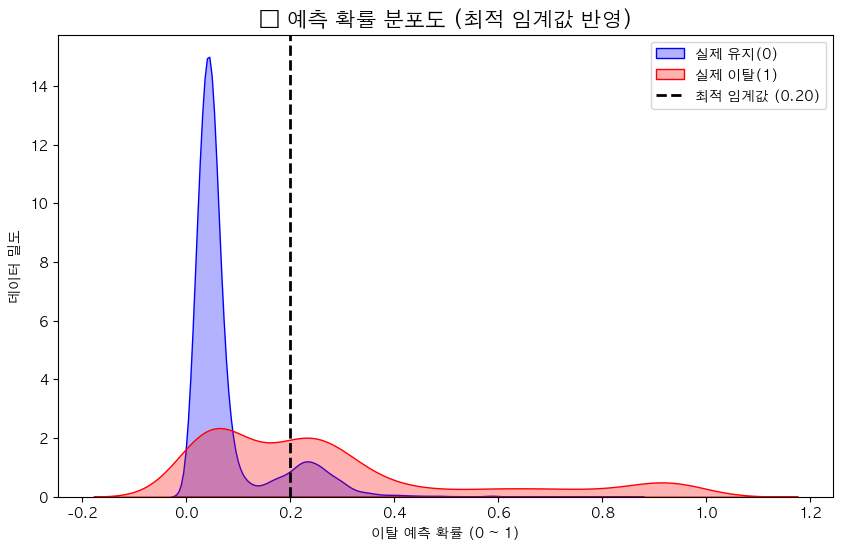

In [28]:
# ==============================================================================
# 📊 [추가] 모델 예측 확률 분포 확인 (그래프 & 텍스트)
# ==============================================================================

# 1. 📈 개선된 확률 분포도 그래프 (최적 임계값 수직선 표시)
plt.figure(figsize=(10, 6))
# 실제 유지(0) 고객의 예측 확률 분포 (파란색)
sns.kdeplot(valid_preds[y_valid == 0], color='blue', fill=True, label='실제 유지(0)', alpha=0.3)
# 실제 이탈(1) 고객의 예측 확률 분포 (빨간색)
sns.kdeplot(valid_preds[y_valid == 1], color='red', fill=True, label='실제 이탈(1)', alpha=0.3)

# 🚨 수정 포인트: 0.5가 아닌 앞에서 찾은 '최적 임계값(best_threshold)'을 선으로 긋습니다.
plt.axvline(best_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'최적 임계값 ({best_threshold:.2f})')

plt.title('📈 예측 확률 분포도 (최적 임계값 반영)', fontsize=15, fontweight='bold')
plt.xlabel('이탈 예측 확률 (0 ~ 1)')
plt.ylabel('데이터 밀도')
plt.legend()
plt.show()